# Universidad del Valle de Guatemala
## Security Data Science
## Implementacion Parte 1

**Nombre:** Gabriel A. Paz Gonzalez  
**Carnet:** 221087

En este notebook voy a trabajar con el dataset **PhiUSIIL** para revisar la data y ver que variables me pueden servir para la primera version del modelo. En esta parte lo que me interesa es entender mejor como se comportan las URLs y con eso decidir que me conviene usar mas adelante.


## 1. Carga de librerias y rutas

Si hace falta instalar dependencias dentro de Jupyter se puede usar:

`%pip install pandas numpy matplotlib seaborn scikit-learn`


In [1]:
from pathlib import Path
import ipaddress
import re
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "data" / "PhiUSIIL_Phishing_URL_Dataset.csv").exists() and (PROJECT_ROOT.parent / "data" / "PhiUSIIL_Phishing_URL_Dataset.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

phiusiil_path = PROJECT_ROOT / "data" / "PhiUSIIL_Phishing_URL_Dataset.csv"
selected_features_path = PROJECT_ROOT / "data" / "phiusiil_url_only_features.csv"
feature_scores_path = PROJECT_ROOT / "data" / "feature_scores_url_only.csv"


## 2. Dataset a utilizar

Para esta implementacion voy a usar el dataset **PhiUSIIL Phishing URL (Website)**. No es un dataset construido por mi, sino una base publica que ya viene con varias caracteristicas de la URL y una etiqueta para distinguir entre casos legitimos y phishing. Lo escogi porque me sirve para trabajar esta primera parte del proyecto sin complicar demasiado la preparacion de datos, y porque tiene suficientes columnas para hacer analisis exploratorio e ingenieria de caracteristicas.


In [2]:
df = pd.read_csv(phiusiil_path, encoding="utf-8-sig")
df["label"] = pd.to_numeric(df["label"], errors="coerce")

missing_labels = int(df["label"].isna().sum())
if missing_labels > 0:
    print(f"Se encontraron {missing_labels} filas sin label o con valores invalidos. Esas filas se eliminaran.")

df = df[df["label"].isin([0, 1])].copy()
df["label"] = df["label"].astype(int)
df["is_phishing"] = (df["label"] == 0).astype(int)
df["label_name"] = df["is_phishing"].map({1: "phishing", 0: "legitimate"})

print("Archivo cargado:", phiusiil_path.name)
print("Filas y columnas:", df.shape)
df.head()


Se encontraron 1 filas sin label o con valores invalidos. Esas filas se eliminaran.
Archivo cargado: PhiUSIIL_Phishing_URL_Dataset.csv
Filas y columnas: (96286, 58)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label,is_phishing,label_name
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24.0,0.0,com,100.0,1.000000,0.522907,0.061933,3.0,1.0,0.0,0.0,0.0,18.0,0.581,0.0,0.0,0.0,0.0,0.0,1.0,0.032,1.0,558.0,9381.0,1.0,à¸‚à¹ˆà¸²à¸§à¸ªà¸” à¸‚à¹ˆà¸²à¸§à¸§à¸±à¸™à¸™à¸µ...,0.000000,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,34.0,20.0,28.0,119.0,0.0,124.0,1,0,legitimate
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16.0,0.0,de,100.0,0.666667,0.032650,0.050207,2.0,1.0,0.0,0.0,0.0,9.0,0.391,0.0,0.0,0.0,0.0,0.0,2.0,0.087,1.0,618.0,9381.0,1.0,johannes gutenberg-universitÃ¤t mainz,55.555556,55.555556,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,9.0,8.0,39.0,0.0,217.0,1,0,legitimate
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22.0,0.0,uk,100.0,0.866667,0.028555,0.064129,2.0,2.0,0.0,0.0,0.0,15.0,0.517,0.0,0.0,0.0,0.0,0.0,2.0,0.069,1.0,467.0,682.0,1.0,voice fm southampton,46.666667,46.666667,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,10.0,2.0,7.0,42.0,2.0,5.0,1,0,legitimate
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19.0,0.0,com,100.0,1.000000,0.522907,0.057606,3.0,1.0,0.0,0.0,0.0,13.0,0.500,0.0,0.0,0.0,0.0,0.0,1.0,0.038,1.0,6356.0,26824.0,1.0,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,1.0,12.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,3.0,27.0,15.0,22.0,1.0,31.0,1,0,legitimate
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26.0,0.0,org,100.0,1.000000,0.079963,0.059441,3.0,1.0,0.0,0.0,0.0,20.0,0.606,0.0,0.0,0.0,0.0,0.0,1.0,0.030,1.0,6089.0,28404.0,1.0,fundaciÃ³n rewilding argentina,100.000000,100.000000,0.0,1.0,1.0,1.0,1.0,1.0,0.0,2.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,244.0,15.0,34.0,72.0,1.0,85.0,1,0,legitimate


En esta parte ya puedo ver que el archivo quedo limpio despues de quitar una fila que venia con problema en la etiqueta. Al final me quede con **96,286 registros**, y eso me sirve porque sigo teniendo suficiente informacion para revisar patrones en las URLs sin quedarme con una muestra demasiado pequena.


## 3. Analisis exploratorio del dataset e identificacion de caracteristicas clave


In [3]:
resumen_inicial = pd.Series({
    "filas": len(df),
    "columnas": df.shape[1],
    "nulos_totales": int(df.isna().sum().sum()),
    "urls_duplicadas": int(df.duplicated(subset=["URL"]).sum()),
    "phishing": int(df["is_phishing"].sum()),
    "legitimate": int((df["is_phishing"] == 0).sum()),
})

resumen_inicial


,0
filas,96286
columnas,58
nulos_totales,0
urls_duplicadas,64
phishing,40537
legitimate,55749


Este resumen me sirve para ubicarme rapido en la base. Aqui puedo ver cuantas filas tengo, cuantas columnas hay, si quedaron nulos y si hay URLs repetidas. Con esto ya me hago una idea de que tan ordenada esta la data antes de seguir con el analisis.


In [4]:
class_distribution = df["label_name"].value_counts().reset_index()
class_distribution.columns = ["class", "count"]
class_distribution["pct"] = class_distribution["count"] / len(df)
class_distribution


,class,count,pct
0,legitimate,55749,0.578994
1,phishing,40537,0.421006


/tmp/ipykernel_311/1050308987.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_distribution, x="class", y="count", palette="Blues")


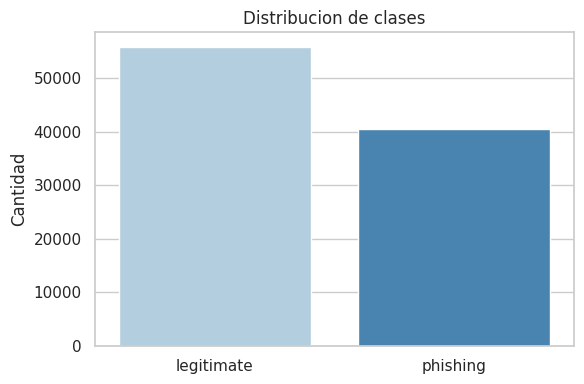

In [5]:
plt.figure(figsize=(6, 4))
sns.barplot(data=class_distribution, x="class", y="count", palette="Blues")
plt.title("Distribucion de clases")
plt.xlabel("")
plt.ylabel("Cantidad")
plt.tight_layout()


Esta grafica me sirve para ver de una manera mas rapida como estan repartidos los casos legitimos y los de phishing. Aqui noto que hay mas ejemplos legitimos (**55,749**) que de phishing (**40,537**), pero igual las dos clases aparecen bastante, asi que me va a servir para comparar ambas sin que una quede demasiado pequena.


In [6]:
df[[
    "URLLength",
    "DomainLength",
    "URLSimilarityIndex",
    "TLDLegitimateProb",
    "NoOfSubDomain",
    "SpacialCharRatioInURL",
]].describe().T


,count,mean,std,min,25%,50%,75%,max
URLLength,96286.0,33.871736,35.760000,13.000000,23.000000,27.000000,33.000000,5794.000000
DomainLength,96286.0,21.331949,8.905742,4.000000,16.000000,20.000000,24.000000,110.000000
URLSimilarityIndex,96286.0,79.258489,28.381593,0.155574,59.053422,100.000000,100.000000,100.000000
TLDLegitimateProb,96286.0,0.261011,0.251438,0.000000,0.006411,0.079963,0.522907,0.522907
NoOfSubDomain,96286.0,1.167792,0.588046,0.000000,1.000000,1.000000,1.000000,10.000000
SpacialCharRatioInURL,96286.0,0.062384,0.031801,0.000000,0.038000,0.050000,0.081000,0.329000


Aqui lo que voy a tomar mas en cuenta no es aprenderme cada numero, sino ver si hay patrones que me puedan servir despues. Por ejemplo, ya se nota que hay URLs bastante largas y algunos casos extremos. Eso me interesa porque justo ese tipo de cosas puede ayudarme a diferenciar mejor los enlaces normales de los sospechosos.


## 4. Algunas variables del dataset

En esta parte voy a revisar algunas variables que desde el inicio me parecen utiles, como la longitud de la URL, la longitud del dominio, la similitud de la URL y la probabilidad de legitimidad del TLD. La idea es ver si de verdad me pueden servir o si no aportan tanto como parecia.


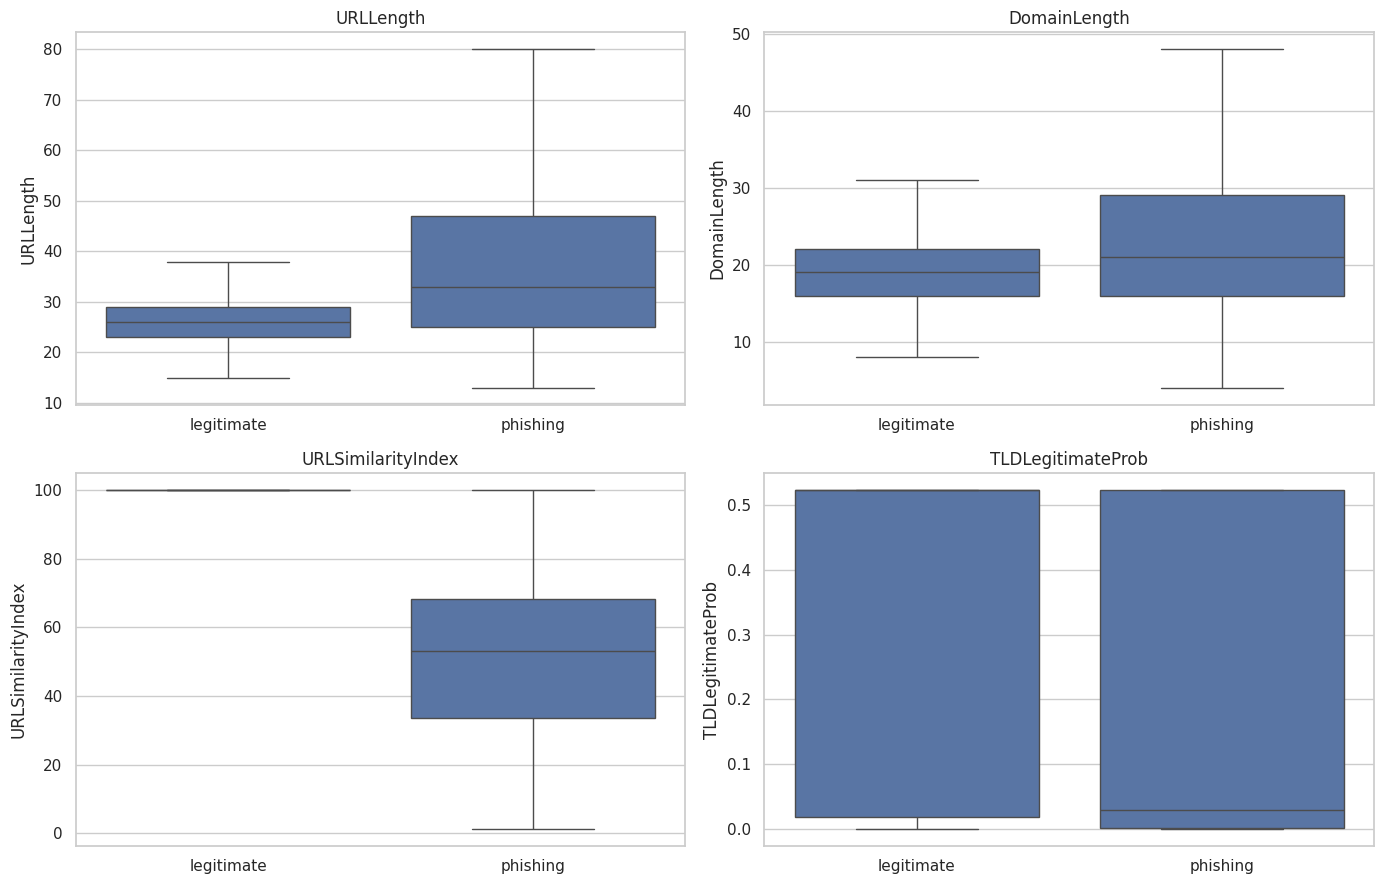

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sample_df = df.sample(n=min(30000, len(df)), random_state=42)
eda_features = ["URLLength", "DomainLength", "URLSimilarityIndex", "TLDLegitimateProb"]

for ax, feature in zip(axes.flat, eda_features):
    sns.boxplot(data=sample_df, x="label_name", y=feature, ax=ax, showfliers=False)
    ax.set_title(feature)
    ax.set_xlabel("")

plt.tight_layout()


Estas graficas me sirven para comparar mejor las dos clases. Aqui puedo ver que los casos de phishing tienden a tener **URLs mas largas** y tambien **dominios un poco mas largos**, mientras que los casos legitimos se ven mas estables.

Lo que mas me llama la atencion es `URLSimilarityIndex`, porque en los casos legitimos aparece bastante alto y en phishing baja mucho mas. Tambien `TLDLegitimateProb` me puede servir, porque se mira un poco mejor en paginas legitimas. Con esto ya empiezo a ver cuales variables podria conservar para la siguiente etapa.


In [8]:
df.groupby("label_name")[[
    "IsHTTPS",
    "HasTitle",
    "HasDescription",
    "HasPasswordField",
    "HasObfuscation",
]].mean()


,IsHTTPS,HasTitle,HasDescription,HasPasswordField,HasObfuscation
label_name,,,,,
legitimate,1.000000,0.998834,0.734255,0.139375,0.000000
phishing,0.462368,0.666058,0.043269,0.048795,0.004588


Esta tabla me sirve para revisar algunas senales mas concretas. Aqui se ve que en los ejemplos legitimos casi siempre aparece **HTTPS**, y tambien es mucho mas comun que tengan titulo y descripcion. En phishing eso baja bastante.

Yo no voy a tomar una sola de estas cosas como prueba suficiente, pero si me pueden servir como apoyo. Si varias de estas senales se juntan en un mismo caso, entonces ya me puede dar una mejor idea de que tan sospechosa es una URL.


## 4. Generacion y seleccion de caracteristicas a utilizar

Aqui voy a crear algunas variables manuales directamente desde la URL. Esto me sirve para complementar lo que ya trae PhiUSIIL y para quedarme con senales que yo mismo pueda entender mejor al momento de explicar por que una URL parece sospechosa.


In [9]:
suspicious_tokens = [
    "login",
    "verify",
    "account",
    "update",
    "secure",
    "signin",
    "confirm",
    "password",
    "wallet",
    "bank",
]

def shannon_entropy(text):
    if not text:
        return 0.0
    counts = pd.Series(list(text)).value_counts(normalize=True)
    return float(-(counts * np.log2(counts)).sum())

def extract_url_features(url):
    url = str(url)
    parsed = urlparse(url)
    host = parsed.netloc.split("@")[-1].split(":")[0].lower()
    host_no_www = host[4:] if host.startswith("www.") else host
    host_parts = [part for part in host_no_www.split(".") if part]

    try:
        ipaddress.ip_address(host_no_www)
        has_ip = 1
    except ValueError:
        has_ip = 0

    clean_url = re.sub(r"^https?://", "", url.lower())

    return {
        "raw_entropy_url": shannon_entropy(clean_url),
        "raw_path_length": len(parsed.path or ""),
        "raw_query_length": len(parsed.query or ""),
        "raw_subdomain_count": max(len(host_parts) - 2, 0),
        "raw_has_at_symbol": int("@" in url),
        "raw_has_ip_host": has_ip,
        "raw_digit_count": sum(ch.isdigit() for ch in url),
        "raw_special_count": sum(not ch.isalnum() for ch in clean_url),
        "raw_suspicious_token_hits": sum(token in clean_url for token in suspicious_tokens),
    }

manual_features = df["URL"].apply(extract_url_features).apply(pd.Series)
df = pd.concat([df, manual_features], axis=1)
manual_features.head()


,raw_entropy_url,raw_path_length,raw_query_length,raw_subdomain_count,raw_has_at_symbol,raw_has_ip_host,raw_digit_count,raw_special_count,raw_suspicious_token_hits
0,3.657268,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
1,3.327820,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
2,3.629220,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0
3,3.576618,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
4,3.430457,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


Estas nuevas variables si me pueden servir bastante. Aqui se ve que los casos de phishing suelen tener **mas path**, **mas query**, **mas subdominios**, **mas numeros** y **mas caracteres especiales**. Incluso aparecen mas palabras sospechosas dentro de la URL.

En otras palabras, estas URLs se ven mas cargadas y mas raras. Justamente por eso me interesa conservar estas variables, porque despues las puedo usar para construir una version del modelo que no dependa solo de las columnas originales del dataset.


In [10]:
df.groupby("label_name")[manual_features.columns.tolist()].mean().T


label_name,legitimate,phishing
raw_entropy_url,3.377271,3.824452
raw_path_length,0.000000,7.976811
raw_query_length,0.000000,4.869033
raw_subdomain_count,0.162855,0.725683
raw_has_at_symbol,0.000000,0.013938
raw_has_ip_host,0.000000,0.005402
raw_digit_count,0.051086,4.088314
raw_special_count,2.245673,4.507610
raw_suspicious_token_hits,0.003749,0.082813


## 6. Seleccion inicial de variables

Para esta entrega me voy a quedar con un conjunto `URL-only`, porque en esta primera parte me interesa trabajar solo con senales que salgan de la URL. Eso me sirve para comenzar con algo mas simple y luego, si hace falta, agregar otras cosas mas adelante.


In [11]:
candidate_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "URLSimilarityIndex",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "raw_entropy_url",
    "raw_path_length",
    "raw_query_length",
    "raw_subdomain_count",
    "raw_has_at_symbol",
    "raw_has_ip_host",
    "raw_digit_count",
    "raw_special_count",
    "raw_suspicious_token_hits",
]

print("Cantidad de variables candidatas:", len(candidate_features))


Cantidad de variables candidatas: 31


Este ranking me va a servir como una primera guia para escoger variables. Aqui veo que resaltan `URLSimilarityIndex`, `IsHTTPS` y `raw_path_length`, pero tambien aparecen otras relacionadas con numeros, caracteres especiales y la forma general de la direccion.

No lo voy a tomar como una regla fija, pero si me sirve para respaldar mejor mis decisiones. En lugar de escoger variables solo porque me parecen interesantes, aqui ya tengo una senal de cuales estan ayudando mas dentro de esta base.


In [12]:
samples = []
for _, part in df.groupby("is_phishing"):
    samples.append(part.sample(n=min(len(part), 25000), random_state=42))

sample_df = pd.concat(samples, axis=0).sample(frac=1.0, random_state=42).reset_index(drop=True)
X_sample = sample_df[candidate_features]
y_sample = sample_df["is_phishing"]

mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
)
rf.fit(X_sample, y_sample)

feature_scores = pd.DataFrame({
    "feature": candidate_features,
    "mi_score": mi_scores,
    "rf_importance": rf.feature_importances_,
}).sort_values(["mi_score", "rf_importance"], ascending=False)

feature_scores.head(20)


,feature,mi_score,rf_importance
3,URLSimilarityIndex,0.670836,0.419143
13,LetterRatioInURL,0.371229,0.015845
23,raw_path_length,0.252586,0.096037
21,IsHTTPS,0.243106,0.203121
19,NoOfOtherSpecialCharsInURL,0.214803,0.049524
22,raw_entropy_url,0.200094,0.021379
20,SpacialCharRatioInURL,0.188663,0.015167
29,raw_special_count,0.184867,0.017811
5,TLDLegitimateProb,0.183007,0.009340
28,raw_digit_count,0.160066,0.029394


Esta grafica me sirve para ver mas claro cuales variables pesan mas y cuales no tanto. Las barras mas grandes me dicen que hay unas pocas senales que me pueden ayudar bastante mas que las demas.

Para mi esto es util porque asi puedo justificar mejor por que me quiero quedar con ciertas columnas. Si una variable aparece arriba y ademas tiene sentido con lo que vi antes en las tablas y graficas, entonces me parece buena candidata para usarla en el modelo.


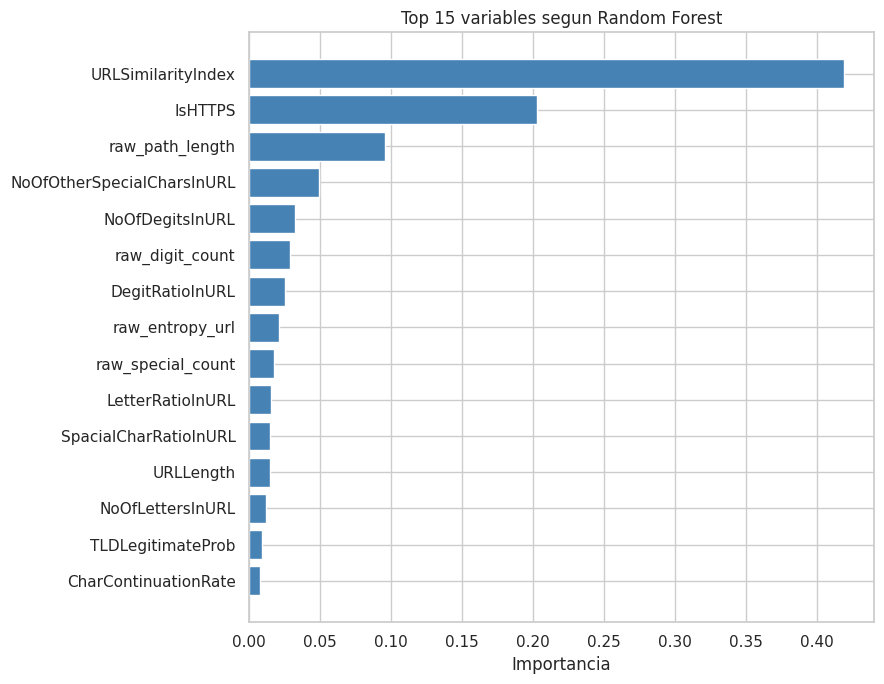

In [13]:
top_features = feature_scores.head(15).sort_values("rf_importance")

plt.figure(figsize=(9, 7))
plt.barh(top_features["feature"], top_features["rf_importance"], color="steelblue")
plt.title("Top 15 variables segun Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()


Al final decidi quedarme con **20 variables**. Lo que busco con esto es tener un grupo de columnas que siga siendo manejable, pero que al mismo tiempo me sirva para representar bastante bien como se comportan estos enlaces. Con este conjunto ya puedo pasar a la siguiente etapa con una base mas ordenada.


## 7. Comentario final

Despues de revisar las tablas y las graficas, yo diria que la URL por si sola ya da varias pistas que me pueden servir. Aqui se ve que los enlaces de phishing tienden a ser mas largos, mas cargados y menos limpios que los legitimos. Tambien hay senales como el uso de HTTPS, el path de la URL y la presencia de numeros o caracteres especiales que me pueden ayudar bastante.

Con todo esto, lo que voy a hacer en la siguiente etapa es empezar con un modelo basado en URL. Me parece una buena forma de arrancar, porque ya tengo un grupo de variables que si me sirve y que puedo justificar con lo que observe en este analisis.
